## 미션11

기계 번역 실습으로, 한국어 문장을 영어로 번역하는 모델을 구축하는 프로젝트.

총 3가지 모델(Seq2Seq 기본 모델, Attention 적용 모델)을 구현하고 학습시키며, 각 모델의 성능을 비교 분석해보겠습니다.


### 가이드라인
- **데이터 전처리**
    - 적절한 토크나이저를 선택하여 한국어, 영어 문장을 토큰화하세요.
    - 문장 길이를 분석하여, 전체 문장의 길이에 맞게 최대 길이(MAX_LENGTH)를 설정하고, 필요한 경우 SOS, EOS, PAD, UNK 등의 특수 토큰을 정의합니다.

- **어휘 사전 구축**
    - 한국어와 영어 각각의 어휘 사전을 구성하세요.
    - 단어의 등장 빈도를 고려하여, 추후 임베딩이나 기타 모델 구성에 활용할 수 있습니다.

- **텐서 변환 및 데이터 로더 구현**
    - 각 문장을 토큰의 인덱스 시퀀스로 변환한 후, 고정 길이에 맞게 PAD 토큰으로 패딩합니다.
    - TensorDataset과 DataLoader를 활용하여 학습 데이터를 배치 단위로 효율적으로 처리할 수 있도록 구현하세요.


- **모델 구현 및 학습**
    - Seq2Seq 모델
        - 기본 GRU 기반의 Encoder-Decoder 모델을 구현하고, Teacher Forcing 기법을 적용해 학습합니다.
    - Attention 모델
        - Bahdanau Attention(Bahdanau 혹은 Luong)을 적용한 디코더를 구현하여, 번역 성능을 높여 보세요.

- **모델 학습 및 평가**
    - 각 모델별로 학습을 진행한 후, 평가 함수를 활용하여 번역 결과를 확인합니다.
    - 무작위 문장 쌍에 대해 모델의 번역 결과를 출력하고, 출력 문장을 정제(특수 토큰 제거 등)하여 성능을 분석해 보세요.

- **추가 실험**
    - 데이터 전처리 방법 개선(예: 불용어 제거, 정규화 등)
    - 모델 구조 변경(레이어 수, 은닉 상태 크기, Attention 기법 수정 등)
    - 하이퍼파라미터 튜닝(학습률, 배치 크기 등)
    - 다양한 평가 지표(예: BLEU 점수) 도입

In [1]:
from google.colab import drive
import zipfile
import os

# 1. Google Drive 마운트
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

# 2.압축 파일 경로 설정
zip_file_name = '일상생활및구어체_한영.zip'
zip_file_path = f'/content/drive/MyDrive/{zip_file_name}'

# 압축 해제할 경로
extract_path = './data'

# 폴더 없으면 생성
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# 3. 압축 해제
try:
    with zipfile.ZipFile(zip_file_path,'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"'{zip_file_path}' 파일이 '{extract_path}' 경로에 성공적으로 압축 해제되었습니다.")

    # 압축 해제된 파일 목록 확인
    print("\n압축 해제된 파일 목록:")
    for filename in os.listdir(extract_path):
        print(os.path.join(extract_path, filename))

except FileNotFoundError:
    print(f"오류: '{zip_file_path}' 파일을 찾을 수 없습니다.")
    print("Google Drive에 파일이 업로드되어 있는지 확인하세요.")

except Exception as e:
    print(f"오류: '{zip_file_path}' 파일의 압축 해제 중 문제가 발생했습니다.")

'/content/drive/MyDrive/일상생활및구어체_한영.zip' 파일이 './data' 경로에 성공적으로 압축 해제되었습니다.

압축 해제된 파일 목록:
./data/일상생활및구어체_한영_train_set.json
./data/일상생활및구어체_한영_valid_set.json


## 로컬에서 압축 제거

In [6]:
import os
import zipfile

# 1.압축 파일 경로 설정
zip_file_name = '일상생활및구어체_한영.zip'
zip_file_path = f'{zip_file_name}'

# 압축 해제할 경로
extract_path = './data'

# 폴더 없으면 생성
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# 2. 압축 해제
try:
    with zipfile.ZipFile(zip_file_path,'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"'{zip_file_path}' 파일이 '{extract_path}' 경로에 성공적으로 압축 해제되었습니다.")

    # 압축 해제된 파일 목록 확인
    print("\n압축 해제된 파일 목록:")
    for filename in os.listdir(extract_path):
        print(os.path.join(extract_path, filename))

except FileNotFoundError:
    print(f"오류: '{zip_file_path}' 파일을 찾을 수 없습니다.")
    print("Google Drive에 파일이 업로드되어 있는지 확인하세요.")

except Exception as e:
    print(f"오류: '{zip_file_path}' 파일의 압축 해제 중 문제가 발생했습니다.")

'일상생활및구어체_한영.zip' 파일이 './data' 경로에 성공적으로 압축 해제되었습니다.

압축 해제된 파일 목록:
./data/일상생활및구어체_한영_train_set.json
./data/일상생활및구어체_한영_valid_set.json


파일을 압축 해제하였으니 파일 구조를 살펴보겠습니다.

- 훈련 데이터 로드 및 구조 확인: 훈련 데이터 파일 './data/일상생활및구어체_한영_train_set.json'을 로드하여 데이터의 구조(예: 키, 값의 형태, 첫 몇 개 엔트리)를 확인합니다.

- 검증 데이터 로드 및 구조 확인: 검증 데이터 파일 './data/일상생활및구어체_한영_valid_set.json'을 로드하여 데이터의 구조(예: 키, 값의 형태, 첫 몇 개 엔트리)를 확인합니다. 훈련 데이터와 구조가 동일한지 비교합니다.

- 데이터 전처리 계획 수립: 로드된 데이터의 구조와 미션 가이드라인(토크나이저 선택, 최대 길이 설정, 특수 토큰 정의, 어휘 사전 구축, 텐서 변환 및 패딩, DataLoader 구현)을 기반으로 상세한 데이터 전처리 계획을 수립합니다.

- Final Task: JSON 파일의 구조 확인 결과와 이에 기반한 데이터 전처리 계획을 요약하여 제시합니다

## 훈련 데이터 로드 및 구조 확인

### Subtask:
훈련 데이터 파일 './data/일상생활및구어체_한영_train_set.json'을 로드하여 데이터의 구조(예: 키, 값의 형태, 첫 몇 개 엔트리)를 확인합니다.

학습 데이터의 구조를 이해하기 위해 JSON 파일을 불러와 최상위 키를 출력하고 처음 몇 개의 항목을 살펴보겠습니다.


In [8]:
import json

# 1. 학습 데이터의 파일 경로를 정의
train_file_path = './data/일상생활및구어체_한영_train_set.json'

# 2. 학습 데이터 JSON 파일을 열고 내용을 불러옵니다.
with open(train_file_path, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

print(f"{train_file_path} 에서 학습 데이터를 성공적으로 불러왔습니다.")

# 3. train_data 딕셔너리의 키를 출력하여 최상위 구조를 파악합니다.
print("\ntrain_data 의 Key:")
print(train_data.keys())

./data/일상생활및구어체_한영_train_set.json 에서 학습 데이터를 성공적으로 불러왔습니다.

train_data 의 Key:
dict_keys(['data'])


In [9]:
# 4. Train_data 처음 5개 항목 출력
print("\ntrain_data:")
for i, item in enumerate(train_data['data'][:5]):
  print(i, ": ", item)


train_data:
0 :  {'sn': 'INTSALDSUT062119042703238', 'data_set': '일상생활및구어체', 'domain': '해외영업', 'subdomain': '도소매유통', 'ko_original': '원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.', 'ko': '원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.', 'mt': 'If you reply to the color you want, we will start making it right away.', 'en': 'If you reply to the color you want, we will start making it right away.', 'source_language': 'ko', 'target_language': 'en', 'word_count_ko': 7, 'word_count_en': 15, 'word_ratio': 2.143, 'file_name': 'INTSAL_DSUT.xlsx', 'source': '크라우드소싱', 'license': 'open', 'style': '구어체', 'included_unknown_words': False, 'ner': None}
1 :  {'sn': 'KTOS062012215152657', 'data_set': '일상생활및구어체', 'domain': '일상생활', 'subdomain': '여행', 'ko_original': '형님 제일 웃긴 그림이 뭔지 알아요.', 'ko': '형님 제일 웃긴 그림이 뭔지 알아요.', 'mt': 'I know what the funniest picture is.', 'en': 'You know what the funniest picture is.', 'source_language': 'ko', 'target_language': 'en', 'word_count_ko': 6, 'word_count_en': 7, 'word_ratio': 1.167, 'file_name': 

번역 모델은 (입력, 출력) 문장 쌍이 필요합니다.

이 데이터를 확인해보니 'ko' -> 입력

'mt' -> 출력으로 리스트를 만들어보아야겠습니다.

In [10]:
# 학습 전용 쌍
pairs = [(item['ko'] , item['en']) for item in train_data['data']]
pairs[:10]

[('원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.',
  'If you reply to the color you want, we will start making it right away.'),
 ('형님 제일 웃긴 그림이 뭔지 알아요.', 'You know what the funniest picture is.'),
 ('>속옷을?', '>Underwear?'),
 ('그래도 가격이 꽤 비싸니까 많이 살게요.',
  'I wont buy a lot though since the price is still quite high.'),
 ('AAA님, 제가 회의에서 화를 냈던 점 정말 사과드리고 싶습니다.',
  'Dear AAA, I really want to apologize for my anger at the meeting.'),
 ('>회식하거든.', ">We're having a get-together."),
 ('돈은 어디에 투자하셨나요?', 'Where did you invest the money?'),
 ('예 이게 빅데이터 빅이네요.', 'Yes, the is big data is big.'),
 ('따라서 부동산 소유자는 종종 비어 있는 값비싼 부동산을 남게 됩니다.',
  'Real estate owners are therefore left with expensive estates which are often vacant.'),
 ('귀사와의 계약을 취소함에 대해 죄송하게 생각하며, 이에 대한 양해를 구합니다.',
  'We apologize for canceling the contract with your company and ask for your understanding.')]

`>` 같은 노이즈가 있는 걸 확인하였습니다.

전처리단계에서 노이즈를 지워보겠습니다.

하지만 물음표, 느낌표, 마침점은 번역 해석에서 중요한 부분이기 때문에

노이즈 기호는 `>` 는 val 데이터도 있는지 확인해보겠습니다.

In [31]:
def count_symbol(data, key, symbol):
    return sum(symbol in item[key] for item in data)

In [32]:
train_file_path = './data/일상생활및구어체_한영_train_set.json'
valid_file_path = './data/일상생활및구어체_한영_valid_set.json'

with open(train_file_path, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open(valid_file_path, 'r', encoding='utf-8') as f:
    valid_data = json.load(f)

train_cnt = count_symbol(train_data["data"], "ko", ">")
val_cnt   = count_symbol(valid_data["data"], "ko", ">")

print(train_cnt, val_cnt)

282515 35211


train , val 둘다 꽤나 자주 나오는걸 확인하였고 `>` 을 제거 하는 함수를 작성하겠습니다.


In [33]:
def clean_sentence(sentence):
  sentence = sentence.replace('>','')
  return sentence.strip()

In [53]:
pairs = [(clean_sentence(item['ko']), clean_sentence(item['en']))
    for item in train_data['data']]

pairs[:10]

[('원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.',
  'If you reply to the color you want, we will start making it right away.'),
 ('형님 제일 웃긴 그림이 뭔지 알아요.', 'You know what the funniest picture is.'),
 ('속옷을?', 'Underwear?'),
 ('그래도 가격이 꽤 비싸니까 많이 살게요.',
  'I wont buy a lot though since the price is still quite high.'),
 ('AAA님, 제가 회의에서 화를 냈던 점 정말 사과드리고 싶습니다.',
  'Dear AAA, I really want to apologize for my anger at the meeting.'),
 ('회식하거든.', "We're having a get-together."),
 ('돈은 어디에 투자하셨나요?', 'Where did you invest the money?'),
 ('예 이게 빅데이터 빅이네요.', 'Yes, the is big data is big.'),
 ('따라서 부동산 소유자는 종종 비어 있는 값비싼 부동산을 남게 됩니다.',
  'Real estate owners are therefore left with expensive estates which are often vacant.'),
 ('귀사와의 계약을 취소함에 대해 죄송하게 생각하며, 이에 대한 양해를 구합니다.',
  'We apologize for canceling the contract with your company and ask for your understanding.')]

#### 토크나이저 선택

Seq2Seq / Attention 구조 이해가 목적이기에

- 한국어: 공백 기반 토크나이징

- 영어: 공백 + 소`문자

로 토크나이저 해보겠습니다.

그리고 허깅페이스 실습을 위해서
`facebook/mbart-large-50-many-to-many-mmt` 로도 실습해보겠습니다.

In [35]:
# 토크나이저 선택
# 한국어, 영어 따로 진행
import re

def tokenize_ko(sentence):
  # 구두점 앞뒤에 공백 추가 후 spl`it
  sentence = re.sub(r'([?.!,])', r' \1',sentence)
  return sentence.split()

def tokenize_en(sentence):
  # 구두점 분리 + 소문자 변환
  sentence = re.sub(r'([?.!,])',r' \1', sentence)
  sentence = sentence.lower()
  return sentence.split()


In [36]:
pairs = [(tokenize_ko(item['ko']), tokenize_en(item['en']))
    for ko, en in pairs]
# 똑같은 문장만 복사되어 오류
pairs[:10]

[(['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과드리고', '싶습니다', '.'],
  ['dear',
   'aaa',
   ',',
   'i',
   'really',
   'want',
   'to',
   'apologize',
   'for',
   'my',
   'anger',
   'at',
   'the',
   'meeting',
   '.']),
 (['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과드리고', '싶습니다', '.'],
  ['dear',
   'aaa',
   ',',
   'i',
   'really',
   'want',
   'to',
   'apologize',
   'for',
   'my',
   'anger',
   'at',
   'the',
   'meeting',
   '.']),
 (['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과드리고', '싶습니다', '.'],
  ['dear',
   'aaa',
   ',',
   'i',
   'really',
   'want',
   'to',
   'apologize',
   'for',
   'my',
   'anger',
   'at',
   'the',
   'meeting',
   '.']),
 (['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과드리고', '싶습니다', '.'],
  ['dear',
   'aaa',
   ',',
   'i',
   'really',
   'want',
   'to',
   'apologize',
   'for',
   'my',
   'anger',
   'at',
   'the',
   'meeting',
   '.']),
 (['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과

In [54]:
pairs = [(tokenize_ko(ko), tokenize_en(en))
         for ko, en in pairs]

pairs[:10]

[(['원하시는', '색상을', '회신해', '주시면', '바로', '제작', '들어가겠습니다', '.'],
  ['if',
   'you',
   'reply',
   'to',
   'the',
   'color',
   'you',
   'want',
   ',',
   'we',
   'will',
   'start',
   'making',
   'it',
   'right',
   'away',
   '.']),
 (['형님', '제일', '웃긴', '그림이', '뭔지', '알아요', '.'],
  ['you', 'know', 'what', 'the', 'funniest', 'picture', 'is', '.']),
 (['속옷을', '?'], ['underwear', '?']),
 (['그래도', '가격이', '꽤', '비싸니까', '많이', '살게요', '.'],
  ['i',
   'wont',
   'buy',
   'a',
   'lot',
   'though',
   'since',
   'the',
   'price',
   'is',
   'still',
   'quite',
   'high',
   '.']),
 (['AAA님', ',', '제가', '회의에서', '화를', '냈던', '점', '정말', '사과드리고', '싶습니다', '.'],
  ['dear',
   'aaa',
   ',',
   'i',
   'really',
   'want',
   'to',
   'apologize',
   'for',
   'my',
   'anger',
   'at',
   'the',
   'meeting',
   '.']),
 (['회식하거든', '.'], ["we're", 'having', 'a', 'get-together', '.']),
 (['돈은', '어디에', '투자하셨나요', '?'],
  ['where', 'did', 'you', 'invest', 'the', 'money', '?']),
 (['예', '이게', '빅데이

구두점과 소문자 변환이 잘 되어있음을 확인하였습니다.

#### 문장 길이 분석하겠습니다.

In [55]:
# 1. 문장 길이 분석
ko_lengths = []
en_lengths = []

ko_lengths = [len(ko) for ko, en in pairs]
en_lengths = [len(en) for ko, en in pairs]

# 2. 통계 확인
import numpy as np
print(f"한국어 평균 길이: {np.mean(ko_lengths):.2f}, 최대 길이: {np.max(ko_lengths)}, 최소 길이: {np.min(ko_lengths):.2f}")
print(f"한국어 최대 길이: {np.max(ko_lengths)}")
print(f"한국어 95% 길이: {np.percentile(ko_lengths,95)}")

print(f"\n영어 평균 길이: {np.mean(en_lengths):.2f}, 최대 길이: {np.max(en_lengths)}, 최소 길이: {np.min(en_lengths):.2f}")
print(f"영어 최대 길이: {np.max(en_lengths)}")
print(f"영어 95% 길이: {np.percentile(en_lengths,95)}")

한국어 평균 길이: 7.78, 최대 길이: 79, 최소 길이: 1.00
한국어 최대 길이: 79
한국어 95% 길이: 15.0

영어 평균 길이: 11.32, 최대 길이: 156, 최소 길이: 1.00
영어 최대 길이: 156
영어 95% 길이: 23.0


In [ ]:
import platform
import matplotlib.pyplot as plt
def set_korean_font():
    system = platform.system()
    
    if system == 'Darwin':  # macOS
        fonts = ['AppleGothic', 'AppleMyungjo']
    elif system == 'Windows':  # Windows
        fonts = ['Malgun Gothic', 'NanumGothic', 'Gulim']
    else:  # Linux
        fonts = ['NanumGothic', 'NanumBarunGothic', 'DejaVu Sans']
    
    # 사용 가능한 폰트 찾기
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    for font in fonts:
        if font in available_fonts:
            plt.rc('font', family=font)
            print(f"설정된 폰트: {font}")
            break
    else:
        print("한글 폰트를 찾을 수 없습니다. 기본 폰트 사용")
    
    # 마이너스 기호 깨짐 방지
    plt.rc('axes', unicode_minus=False)

전체 pairs 개수: 1200000
ko_lengths 개수: 1200000

첫 20개 문장 길이:
[8, 7, 2, 7, 11, 2, 4, 5, 11, 12, 4, 13, 7, 9, 9, 9, 12, 5, 8, 7]
[17, 8, 2, 14, 15, 5, 7, 9, 14, 15, 6, 20, 12, 14, 16, 19, 17, 7, 7, 13]
설정된 폰트: AppleGothic


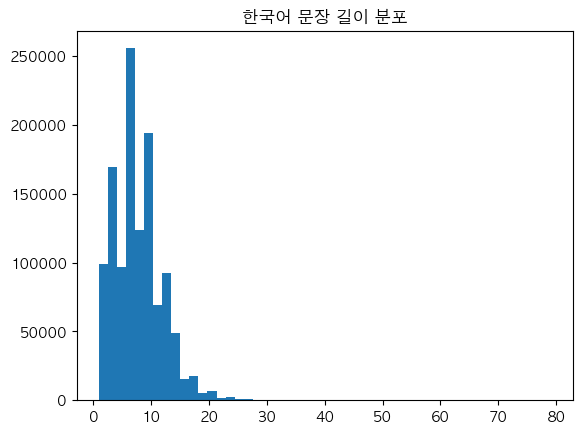

In [56]:
# 데이터 개수 확인
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

print(f"전체 pairs 개수: {len(pairs)}")
print(f"ko_lengths 개수: {len(ko_lengths)}")

# 실제 길이 분포 확인
print(f"\n첫 20개 문장 길이:")
print(ko_lengths[:20])
print(en_lengths[:20])

# 히스토그램
plt.hist(ko_lengths, bins=50)

set_korean_font()
plt.title('한국어 문장 길이 분포')

plt.show()

In [57]:
# 3. MAX_LENGTH 설정
MAX_LENGTH = {
    "ko": int(np.percentile(ko_lengths, 95)),
    "en": int(np.percentile(en_lengths, 95))
}

print("MAX_LENGTH:", MAX_LENGTH)

MAX_LENGTH: {'ko': 15, 'en': 23}


리스트 컴프리헨션에서 루프 변수를 잘 못 사용해서 오류가 나왔으나 수정하였습니다.

### 특수 토큰 정의 & 어휘 사전 구축

시작하겠습니다.

In [93]:
# 4. 특수 토큰 정의
SOS_TOKEN = 0 # Start of Sentence
EOS_TOKEN = 1 # End of Sentence
PAD_TOKEN = 2 # Padding Token
UNK_TOKEN = 3 # Unknown Token

print("특수 토큰이 정의되었습니다.")
print("SOS_TOKEN:", SOS_TOKEN)
print("EOS_TOKEN:", EOS_TOKEN)
print("PAD_TOKEN:", PAD_TOKEN)
print("UNK_TOKEN:", UNK_TOKEN)

특수 토큰이 정의되었습니다.
SOS_TOKEN: 0
EOS_TOKEN: 1
PAD_TOKEN: 2
UNK_TOKEN: 3


In [ ]:
# 5. 어휘 사전 구축
class Vocab:
    def __init__(self):
        self.word2idx = {"<PAD>":PAD_TOKEN, "<SOS>":SOS_TOKEN,
                         "<EOS>":EOS_TOKEN, "<UNK>":UNK_TOKEN}
        self.idx2word = {PAD_TOKEN:"<PAD>", SOS_TOKEN:"<SOS>",
                         EOS_TOKEN:"<EOS>", UNK_TOKEN:"<UNK>"}
        self.word2count = {}
        self.n_words = 4 # 특수 토큰 개수
        
    def add_sentence(self, sentence):
        """
        문장(토큰 리스트)을 받아서 어휘 사전에 추가
        """
        for word in sentence:
            self.add_word(word)
            
    def add_word(self, word):
        """
        단어를 어휘에 추가
        """
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.word2count[word] = 1
            self.n_words += 1
        else:
            self.word2count[word]+= 1
            
         
# 한국어, 영어 어휘 사전 생성
ko_vocab = Vocab()
en_vocab = Vocab()

# pairs에서 어휘 추가
for ko_tokens, en_tokens in pairs:
    ko_vocab.add_sentence(ko_tokens)
    en_vocab.add_sentence(en_tokens)

print(f"한국어 어휘 사전 크기: {ko_vocab.n_words}")
print(f"영어 어휘 사전 크기: {en_vocab.n_words}")

한국어 어휘 사전 크기: 533431
영어 어휘 사전 크기: 81910


KeyboardInterrupt: 

In [ ]:
# 한국어 어휘 사전 확인 (처음 10개 단어-인덱스 쌍)
print("=== 한국어 어휘 사전 (word2idx) ===")
ko_items = list(ko_vocab.word2idx.items())[4:14]
print(ko_items)

print("\n=== 한국어 어휘 사전 (idx2word) ===")
ko_items = list(ko_vocab.idx2word.items())[4:14]
print(ko_items)

# 영어 어휘 사전 확인 (처음 10개 단어-인덱스 쌍)
print("\n=== 영어 어휘 사전 (word2idx) ===")
en_items = list(en_vocab.word2idx.items())[4:14]
print(en_items)

print("\n=== 영어 어휘 사전 (idx2word) ===")
en_items = list(en_vocab.idx2word.items())[4:14]
print(en_items)

# 가장 자주 등장하는 한국어 단어 10개
from collections import Counter
ko_most_common = Counter(ko_vocab.word2count).most_common(10)
print("\n=== 한국어 가장 자주 등장하는 단어 10개 ===")
print(ko_most_common)

# 가장 자주 등장하는 영어 단어 10개
en_most_common = Counter(en_vocab.word2count).most_common(10)
print("\n=== 영어 가장 자주 등장하는 단어 10개 ===")
print(en_most_common)

=== 한국어 어휘 사전 (word2idx) ===
[('원하시는', 4), ('색상을', 5), ('회신해', 6), ('주시면', 7), ('바로', 8), ('제작', 9), ('들어가겠습니다', 10), ('.', 11), ('형님', 12), ('제일', 13)]

=== 한국어 어휘 사전 (idx2word) ===
[(4, '원하시는'), (5, '색상을'), (6, '회신해'), (7, '주시면'), (8, '바로'), (9, '제작'), (10, '들어가겠습니다'), (11, '.'), (12, '형님'), (13, '제일')]

=== 영어 어휘 사전 (word2idx) ===
[('if', 4), ('you', 5), ('reply', 6), ('to', 7), ('the', 8), ('color', 9), ('want', 10), (',', 11), ('we', 12), ('will', 13)]

=== 영어 어휘 사전 (idx2word) ===
[(4, 'if'), (5, 'you'), (6, 'reply'), (7, 'to'), (8, 'the'), (9, 'color'), (10, 'want'), (11, ','), (12, 'we'), (13, 'will')]

=== 한국어 가장 자주 등장하는 단어 10개 ===
[('.', 1054334), (',', 277072), ('?', 133941), ('수', 101991), ('있습니다', 98638), ('저희', 43139), ('이', 41804), ('있는', 33423), ('네', 32363), ('합니다', 27192)]

=== 영어 가장 자주 등장하는 단어 10개 ===
[('.', 1068677), (',', 552956), ('the', 551647), ('to', 343575), ('you', 307903), ('a', 274841), ('and', 234272), ('i', 227924), ('it', 212103), ('is', 206966)]


의문점이 들었습니다. 기계 학습에서 불용어를 지우지 않아야 할까요?

확인 결과

불용어를 제거 하면 언어 모델 자체가 성립하지 않습니다.

ko : 나는 학교에 간다

en : I am going to school

불용어 제거 시

going school

문법이 붕괴됩니다.

의미 없는 특수 기호만 제한적으로 제거하고 다음 과정으로 넘어가겠습니다.

In [ ]:
# 6.문장을 인덱스 시퀀스로 변환

def sentence_to_indices(vocab, sentence):
    """
    문장(토큰 리스트)을 받아서 인덱스 리스트로 변환
    sentence(list): 토큰 리스트
    """
    indexes = [vocab.word2idx.get(word, UNK_TOKEN) for word in sentence]
    indexes.append(EOS_TOKEN) # EOS 토큰 추가
    return indexes

In [ ]:
sentence_ko , sentence_en = pairs[73]
ko_indexes = sentence_to_indices(ko_vocab, sentence_ko)
en_indexes = sentence_to_indices(en_vocab, sentence_en)

print(f"한국어 문장 :{' '.join(sentence_ko)}")
print(f"\n한국어 인덱스 :{ko_indexes}")
print(f"\n영어 문장 :{' '.join(sentence_en)}")
print(f"\n영어 인덱스 :{en_indexes}")

한국어 문장 :최상의 품질을 위해서 씨앗 키트를 재배기에 투입한 후 엽채류는 4주 이후 , 허브류는 6주 이후 , 화훼류는 8주 이후에 일괄 수확하는 것을 추천합니다 .

한국어 인덱스 :[422, 423, 209, 424, 425, 426, 427, 428, 429, 430, 431, 27, 432, 433, 431, 27, 434, 435, 436, 437, 438, 439, 440, 11, 1]

영어 문장 :for the best quality , it is recommended to collectively harvest leaf vegetables after 4 weeks , herbs after 6 weeks , and flowers after 8 weeks after putting seed kits into the cultivator .

영어 인덱스 :[42, 8, 372, 304, 11, 16, 24, 150, 7, 373, 374, 375, 376, 377, 378, 379, 11, 380, 377, 381, 379, 11, 73, 382, 377, 383, 379, 377, 384, 385, 386, 228, 8, 387, 19, 1]


In [ ]:
# 7. 패딩 함수

def pad_sequence(indexes, max_length, pad_token=PAD_TOKEN):
    """
    인덱스 시퀀스를 max_length에 맞게 패딩하거나 자르기
    """
    if len(indexes) < max_length:
        # 패딩 추가
        indexes = indexes + [pad_token] * (max_length - len(indexes))
    else:
        # 자르기
        indexes = indexes[:max_length]
    return indexes
    

In [ ]:
padded_ko = pad_sequence(ko_indexes, MAX_LENGTH['ko'])
padded_en = pad_sequence(en_indexes, MAX_LENGTH['en'])

print(f"패딩 전 한국어 길이 :{len(ko_indexes)}, 패딩 후 한국어 길이: {len(padded_ko)}")
print(f"패딩 전 영어 길이 :{len(en_indexes)}, 패딩 후 영어 길이: {len(padded_en)}")

패딩 전 한국어 길이 :20, 패딩 후 한국어 길이: 15
패딩 전 영어 길이 :26, 패딩 후 영어 길이: 23


In [ ]:
# 8. 전체 데이터셋 변환

import torch
# 전체 pairs를 인덱스로 변환 + 패딩까지
ko_tensors = []
en_tensors = []

for ko_tokens, en_tokens in pairs:
    # 인덱스로 변환
    ko_indexes = sentence_to_indices(ko_vocab, ko_tokens)
    en_indexes = sentence_to_indices(en_vocab, en_tokens)
    
    # 패딩
    ko_padded = pad_sequence(ko_indexes, MAX_LENGTH['ko'])
    en_padded = pad_sequence(en_indexes, MAX_LENGTH['en'])
    
    # 리스트에 추가
    ko_tensors.append(ko_padded)
    en_tensors.append(en_padded)

# 리스트를 텐서로 변환
ko_tensors = torch.LongTensor(ko_tensors)
en_tensors = torch.LongTensor(en_tensors)

In [ ]:
# 9. DataLoader 생성

from torch.utils.data import TensorDataset, DataLoader
# TensorDataset 생성
dataset = TensorDataset(ko_tensors, en_tensors)

# DataLoader 생성
BATCH_SIZE = 64

train_loader = DataLoader(dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          drop_last=True)

In [ ]:
print(f"전체 데이터 개수: {len(dataset)}")
print(f"배치 개수: {len(train_loader)}")

# 첫 배치 확인
for ko_batch, en_batch in train_loader:
    print(f"\n첫 배치 shape:")
    print(f"  한국어: {ko_batch.shape}")
    print(f"  영어: {en_batch.shape}")
    print(f"\n첫 샘플:")
    print(f"  한국어 인덱스: {ko_batch[0]}")
    print(f"  영어 인덱스: {en_batch[0]}")
    break

전체 데이터 개수: 1200000
배치 개수: 18750

첫 배치 shape:
  한국어: torch.Size([64, 15])
  영어: torch.Size([64, 23])

첫 샘플:
  한국어 인덱스: tensor([231317,     11,      1,      2,      2,      2,      2,      2,      2,
             2,      2,      2,      2,      2,      2])
  영어 인덱스: tensor([26108,    19,     1,     2,     2,     2,     2,     2,     2,     2,
            2,     2,     2,     2,     2,     2,     2,     2,     2,     2,
            2,     2,     2])


데이터 처리까지 구현하였습니다.

다음 단계인 `Seq2Seq` 모델 구현에 들어가겠습니다.

Step 1. **Encoder 클래스 기반 (GRU 기반)**

Step 2. **Deconder 클래스 (GRU +Teacher Forcing)**


> GRU 로 실행한 이유는 빠르게 학습 할 수 있고, 구조를 이해하기 쉬워서 첫 스타트로 시작하였습니다.

In [ ]:
# 1. Encoder 클래스 기반 (GRU 기반)
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_dim, n_layers=1, dropout=0.5):
        """
        Args:
            input_size(int): 어휘 사전 크기 (ko_vocab.n_words)
            embedding_dim(int): 임베딩 차원
            hidden_dim(int): 은닉 상태 차원
            n_layer(int): RNN 레이어 수
            dropout(float): 드롭아웃 비율
        """
        super(Encoder , self).__init__()
        
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        # 임베딩 레이어
        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx= PAD_TOKEN)
        
        # GPU 레이어
        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            n_layers,
            dropout=(0 if n_layers ==1 else dropout),
            batch_first=True
        )
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input_seqs, input_lengths, hidden=None):
        """
        Args:
            input_seqs (Tensor): (batch_size, seq_len)
            input_lengths (list): 각 문장의 실제 길이 리스트
            hidden (Tensor): 초기 은닉 상태
        Returns:
            outputs (Tensor): (batch_size, seq_len, hidden_dim)
            hidden (Tensor): 마지막 은닉 상태
        """
        # 임베딩 : (batch_size, seq_len, embedding_dim)
        embedded = self.dropout(self.embedding(input_seqs))
        
        # 패딩 압축 (Pack Padded Sequence)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            input_lengths,
            batch_first=True,
            enforce_sorted=False)
        
        # GRU 연산
        output, hidden = self.gru(packed, hidden)
        
        # 압축 해제 (Unpack Padded Sequence)
        # output: (batch_size, seq_len, hidden_dim) 형태로 복원합니다.
        outputs, _ = nn.utils.rnn.pad_packed_sequence(
            output,
            batch_first=True,
            total_length=input_seqs.size(1))
        
        return outputs, hidden

#### GRU 인코더 레이어

**(1) Encoder 역할 (Seq2Seq 맥락)**

기계번역에서 Encoder 는

- 입력 문장 (한국어)을 고정 차원의 표현으로 압축
- 각 시점의 은닉 상태 +마지막 은닉 상태를 Decoder 에 전달

**(2) 임베딩 레이어 역할**
- 정수 토큰 ID -> 연속 벡터
- (batch_size, seq_len) -> (batch_size, seq_len, embedding_dim)

중요 포인트

- **Embedding 은 index lookup**
- 입력 토큰 값은 반드시
    - 0 <= token_id < input_size 여야 합니다.

**(3) Dropout**
- 임베딩 벡터 일부를 랜덤으로 0 처리
- 과적합 방지
- 시퀀스 길이나 구조에는 영향 없음

**(4) Pack/UnPack (가변 길이 처리)**

왜 필요한가

- 패딩(PAD) 을 RNN이 "실제 토큰"으로 처리하지 않게 하기 위해
- 계산량 감소 + 학습 안정성 증가

조건:

- input_lengths[i] 는 반드시
    - 1 이상
    - 해당 시퀀스의 실제 길이
    - padding 제외

**(5) GRU layer**

GRU 내부에서 일어나는 일:

- 시점 t 마다:
    - Reset gate
    - Update gate
- LSTM 보다 파라미터 적고 빠름

출력:

- outputs : 모든 시점의 은닉 상태
- hidden : 마지막 시점의 은닉 상태 (레이어 수만큼)

형태 :

```
outputs : (batch, seq_len, hidden_dim)
hidden : (n_layers, batch, hidden_dim)
```

In [117]:
# 문장 길이 계산 함수
def get_lengths(tensor_batch, pad_token=PAD_TOKEN):
    """
    배치에서 각 문장의 실제 길이를 계산 (패딩 제외)
    Args:
        tensor_batch (Tensor): (batch_size, seq_len)
        pad_token (int): 패딩 토큰 인덱스
    Returns:
        lengths (list): 각 문장의 실제 길이 리스트
    """
    lengths = []
    for seq in tensor_batch:
        length = (seq != pad_token).sum().item()
        lengths.append(length)
    return lengths

In [128]:
# 확인용 인코더 인스턴스 생성
encoder = Encoder(
    input_size = ko_vocab.n_words,
    embedding_dim=256,
    hidden_dim=512,
    n_layers=2,
    dropout=0.5
)

# 작은 배치로 테스트
sample_ko_batch = ko_tensors[:5] # (5, max_length_ko)
print(f"입력 배치 shape: {sample_ko_batch.shape}")

# 문장 길이 계산 (패딩 토큰 제외)
input_lengths = get_lengths(sample_ko_batch)
print(f"각 문장의 실제 길이 :{input_lengths}")

# Encoder 호출
enc_outputs, enc_hidden = encoder(sample_ko_batch, input_lengths)
print(f"\n인코더 출력 shape: {enc_outputs.shape}")
print(f"인코더 마지막 은닉 상태 shape: {enc_hidden.shape}")

입력 배치 shape: torch.Size([5, 15])
각 문장의 실제 길이 :[9, 8, 3, 8, 12]


IndexError: index out of range in self

#### 지속되는 `index out of range in self` 오류

스택 트레이스 핵심 위치 :
```python
self.embedding(input_seqs)
```

&rArr; Embedding 레이어에서 터졌습니다.

**(1) 이 에러가 의미하는 것**
> 입력 토큰 ID 중 하나 이상이<br>input_size -1 보다 크다

**(2) 코드 상황 정리**
```python
encoder = Encoder(
    input_size = ko_vacab.n_words,
    ...
)
```

```python
sample_ko_batch = ko_tensors[:5]
```

**(3) 왜 오류가 나오는것인가**
> **ko_tensors가 현재 ko_vocab과 다른 vocab으로 만들어짐**

예:

- vocab 다시 생성
- vocab에 <PAD>, <SOS>, <EOS> 추가 후
- 기존 tensor 재사용

결과 :

ko_vab.n_word = 8000 <br/>
하지만 ko_tensors 안에 8000 이상 index 존재



In [120]:
print("Step 1: 입력 확인")
print(f"sample_ko_batch shape: {sample_ko_batch.shape}")
print(f"input_lengths: {input_lengths}")

print("\nStep 2: 임베딩")
embedded = encoder.embedding(sample_ko_batch)
print(f"embedded shape: {embedded.shape}")

print("\nStep 3: 패딩 압축 시도")
try:
    packed = nn.utils.rnn.pack_padded_sequence(
        embedded, 
        input_lengths, 
        batch_first=True,
        enforce_sorted=False
    )
    print("패딩 압축 성공!")
except Exception as e:
    print(f"오류 발생: {e}")
    print(f"오류 타입: {type(e)}")

Step 1: 입력 확인
sample_ko_batch shape: torch.Size([5, 15])
input_lengths: [9, 8, 3, 8, 12]

Step 2: 임베딩


IndexError: index out of range in self

In [132]:
# 어디서 오류가 나는지 확인
print("vocab 크기: ", ko_vocab.n_words)
print("토큰 id 최대 크기: ", sample_ko_batch.max().item())
print("토큰 id 최소 크기: ", sample_ko_batch.min().item())
print(f"PAD_TOKEN: {PAD_TOKEN}")

print(f"pairs : {pairs[0]}")

vocab 크기:  4
토큰 id 최대 크기:  35
토큰 id 최소 크기:  1
PAD_TOKEN: 2
pairs : (['원하시는', '색상을', '회신해', '주시면', '바로', '제작', '들어가겠습니다', '.'], ['if', 'you', 'reply', 'to', 'the', 'color', 'you', 'want', ',', 'we', 'will', 'start', 'making', 'it', 'right', 'away', '.'])


```text
vocab 크기:  4
토큰 id 최대 크기:  35
토큰 id 최소 크기:  1
PAD_TOKEN: 2
```
해당 출력은 치명적인 모순

**Embedding 레이어 정의**

```python
self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx= PAD_TOKEN)
```

- input_size = 4
- 허용 가능한 토큰 id 범위는 0,1,2,3

실제 인력 토큰은 35 (sample_ko_batch.max().item())

&rarr; embedding.weight[35] 를 접근하려고 함
&rarr; 존재하지 않음
&rarr; IndexError

왜 vocab 의 크기가 4가 나왔는가?

```python
class Vocab:
    def __inif(self):
        self.word2idx = {"<PAD>":PAD_TOKEN, "<SOS>":SOS_TOKEN,
                         "<EOS>":EOS_TOKEN, "<UNK>":UNK_TOKEN}
        self.n_words = 4
```

이 상태에서 단어를 추가하지 않았거나,<br/>
다른 vocab 으로 토큰화 했거나,<br/>
토큰 &rarr; id 변환 시 vocab 을 잘못 참조했습니다.

